# 1. Bibliotecas

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# 2. Preparação dos dados

In [3]:
df = pd.read_csv('../data/processed/churn_tratado.csv')

# 3. Análise de correlação

In [4]:
df[['tenure','MonthlyCharges','TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


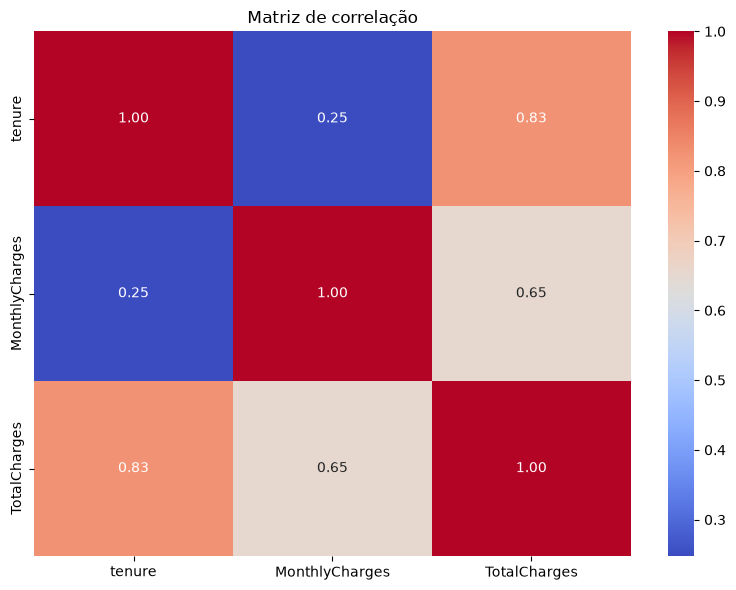

In [5]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()

# 4. Seleção das variáveis

## 4.1 Variáveis numéricas

In [6]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

tenure                                                     \
        count       mean        std  min   25%   50%   75%   max   
Churn                                                              
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      MonthlyCharges             ...               TotalCharges               \
               count       mean  ...   75%     max        count         mean   
Churn                            ...                                           
No            5174.0  61.265124  ...  88.4  118.75       5174.0  2549.911442   
Yes           1869.0  74.441332  ...  94.2  118.35       1869.0  1531.796094   

                                                              
               std    min    25%       50%      75%      max  
Churn                                                         
No     2329.954215   0.00  572.9  1679.525  4262.85  8672.45  
Yes    1890.822994  18.85  134.5   703.550  2331.30  8684.80  

[2 rows x 24 columns]

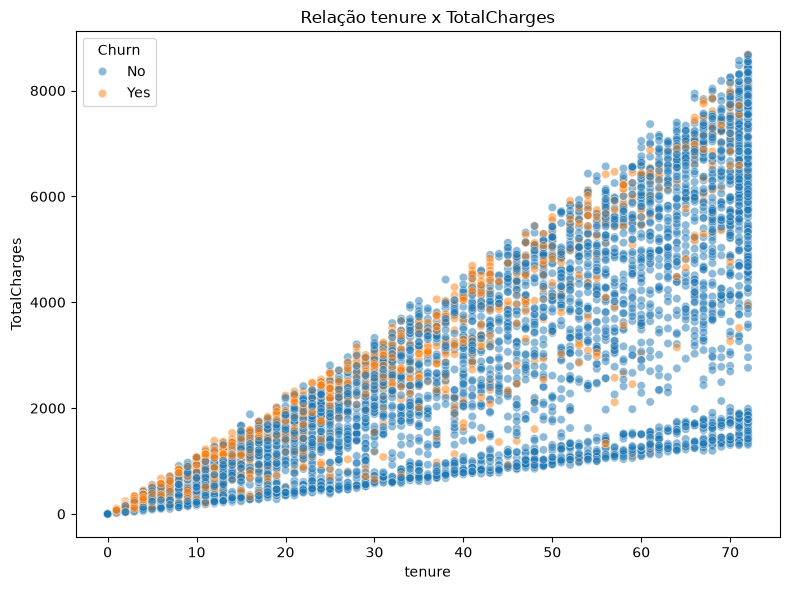

In [7]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="TotalCharges",
    hue="Churn",
    alpha=0.5
)

plt.title("Relação tenure x TotalCharges")
plt.xlabel("tenure")
plt.ylabel("TotalCharges")
plt.tight_layout()
plt.show()

### Análise

Temos uma correlação forte entre **tenure** e **TotalCharges**, com coeficiente de correlação de `0,826`.

Mesmo tendo relação forte, a correlação não é perfeita e o gráfico mostra que diferentes valores de **TotalCharges** podem ocorrer para um mesmo valor de **tenure**.

As duas variáveis serão mantidas e sua contribuição será analisada nas próximas etapas da modelagem.

## 4.2 Variáveis categóricas

In [8]:
col_categorias = df.select_dtypes(include='object').columns

col_categorias = [
    coluna for coluna in col_categorias
    if coluna not in ['customerID','Churn']
]

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_9392\177335686.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col_categorias = df.select_dtypes(include='object').columns


In [9]:
col_categorias.append('SeniorCitizen')

In [10]:
def cramer(tabela):
  chi2 = stats.chi2_contingency(tabela)[0]
  n = tabela.sum().sum()
  r,k = tabela.shape

  return np.sqrt(
      chi2/ (n*min (k-1, r-1))
  )

### Associação com Churn

In [11]:
res_categoricos = []

for coluna in col_categorias:
  tabela = pd.crosstab(df[coluna],df['Churn'])

  v = cramer(tabela)

  res_categoricos.append({
      'variavel': coluna,
      'cramer': v
  })

res_categoricos = pd.DataFrame(res_categoricos)

res_categoricos.sort_values(
    'cramer',
    ascending=False
)

,variavel,cramer
12,Contract,0.410116
6,OnlineSecurity,0.347400
9,TechSupport,0.342916
5,InternetService,0.322455
14,PaymentMethod,0.303359
7,OnlineBackup,0.292316
8,DeviceProtection,0.281580
11,StreamingMovies,0.230951
10,StreamingTV,0.230502
13,PaperlessBilling,0.191498


In [12]:
matriz_cramer = pd.DataFrame(
    index=col_categorias,
    columns=col_categorias,
    dtype=float
)

for coluna1 in col_categorias:
    for coluna2 in col_categorias:
        tabela = pd.crosstab(df[coluna1], df[coluna2])

        matriz_cramer.loc[coluna1, coluna2] = cramer(tabela)

### Associação entre variaveis categoricas

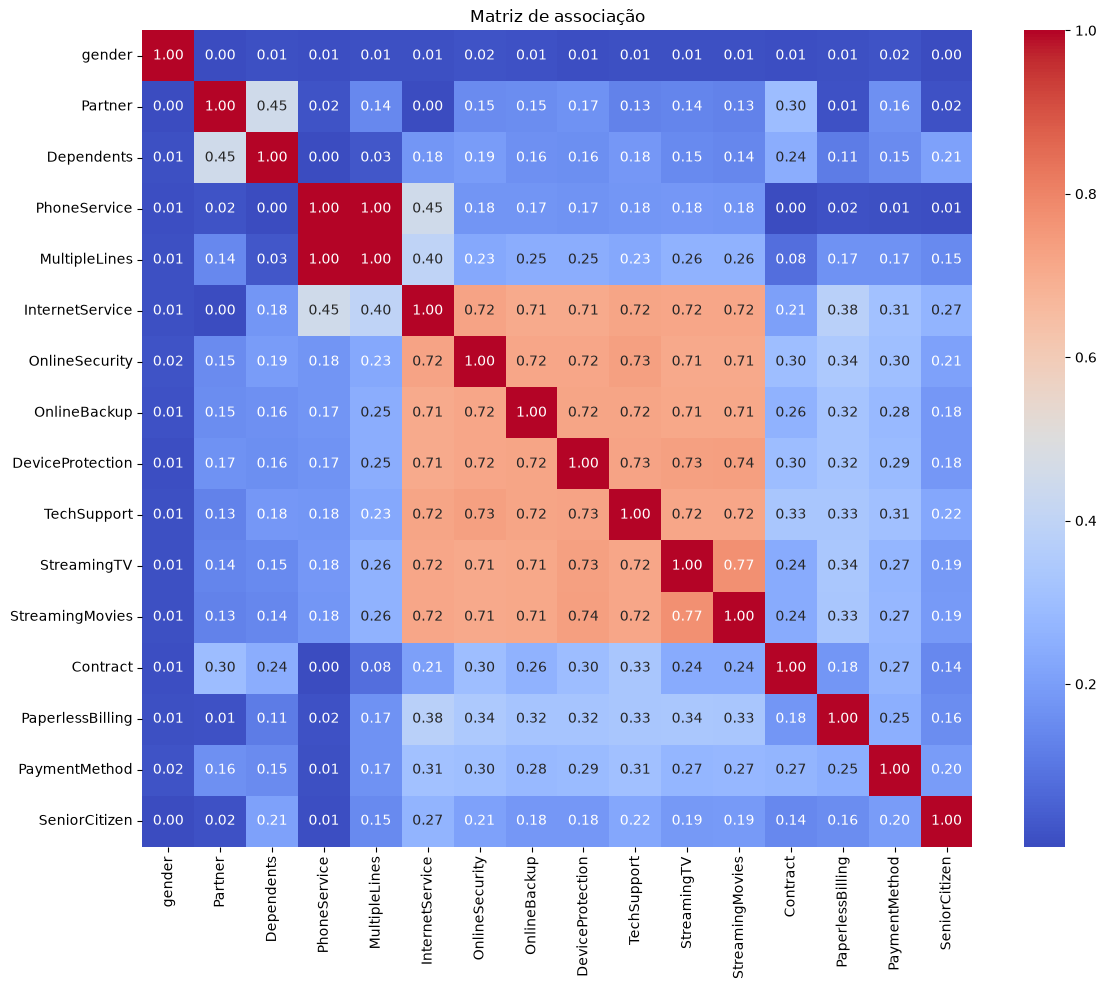

In [13]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz_cramer,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de associação")
plt.tight_layout()
plt.show()

Temos Evidencias de associações mais forte entre algumas variaveis, principalmente entre atributos relacionado a internet.

In [14]:
df_internet = df[df["InternetService"] != "No"]

In [15]:
cramer(
    pd.crosstab(
        df_internet["InternetService"],
        df_internet["DeviceProtection"]
    )
)

np.float64(0.0012252938442984876)

In [16]:
servicos = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for servico in servicos:
    tabela = pd.crosstab(
        df_internet["InternetService"],
        df_internet[servico]
    )

    valor = cramer(tabela)

    print(f"{servico}: {valor:.4f}")

OnlineSecurity: 0.2226
OnlineBackup: 0.0144
DeviceProtection: 0.0012
TechSupport: 0.2122
StreamingTV: 0.1683
StreamingMovies: 0.1588


### Relação estrutural
**PhoneService** e **MultipleLines** tem associação perfeita (`Cramér's V = 1,00`).

Isso acontece porque a categoria `No phone service` em **MultipleLines** está diretamente relacionada a `PhoneService = No`.


### Investigação de possíveis redundâncias

Algumas associações elevadas foram observadas entre variáveis relacionadas aos serviços de internet.

Essas relações foram investigadas considerando também os clientes que possuem um serviço de internet, pois parte da associação inicial estava relacionada às categorias `No internet service`.

Após essa análise, não foi encontrada evidência suficiente para considerar essas variáveis completamente redundantes.

Por isso, as variáveis categóricas serão mantidas inicialmente e sua contribuição será avaliada durante a modelagem.

# 5. Dataset final para modelagem

In [17]:
variaveis_selecionadas = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges"
]

df_modelagem = df[variaveis_selecionadas + ["Churn"]].copy()

df_modelagem.to_csv(
    "../data/processed/churn_modelagem.csv",
    index=False
)